In [1]:
import os
print(os.listdir())

['archive (6).zip', 'content-analysis.ipynb', 'OnlineNewsPopularity.csv']


In [2]:
import pandas as pd

df = pd.read_csv("OnlineNewsPopularity.csv")
print("Shape:", df.shape)
print("First few columns:", df.columns.tolist()[:5])

Shape: (39644, 61)
First few columns: ['url', ' timedelta', ' n_tokens_title', ' n_tokens_content', ' n_unique_tokens']


In [5]:
# Strip leading/trailing spaces from all column names (known quirk of this dataset)
df.columns = df.columns.str.strip()

# Confirm the key columns we'll use are now clean
print("Cleaned. Checking key columns exist:")
for col in ['shares', 'n_tokens_title', 'n_tokens_content', 'num_imgs', 'num_videos']:
    print(f"  {col}: {'YES' if col in df.columns else 'NO'}")

Cleaned. Checking key columns exist:
  shares: YES
  n_tokens_title: YES
  n_tokens_content: YES
  num_imgs: YES
  num_videos: YES


In [6]:
# Which content features correlate most with shares (engagement)?
features = [
    'n_tokens_title',      # title length (word count)
    'n_tokens_content',    # article length
    'num_imgs',            # number of images
    'num_videos',          # number of videos
    'num_hrefs',           # number of links
    'global_subjectivity', # how opinionated the writing is
    'title_sentiment_polarity',  # positive/negative title tone
    'global_sentiment_polarity', # positive/negative article tone
    'num_keywords',        # number of keywords/tags
]

# Keep only features that actually exist, then correlate with shares
features = [f for f in features if f in df.columns]
correlations = df[features + ['shares']].corr()['shares'].drop('shares').sort_values(ascending=False)

print("Correlation of each content feature with SHARES:\n")
print(correlations)

Correlation of each content feature with SHARES:

num_hrefs                    0.045404
num_imgs                     0.039388
global_subjectivity          0.031604
num_videos                   0.023936
num_keywords                 0.021818
title_sentiment_polarity     0.012772
n_tokens_title               0.008783
global_sentiment_polarity    0.004163
n_tokens_content             0.002459
Name: shares, dtype: float64


In [7]:
# Average shares by content channel
channels = {
    'Lifestyle': 'data_channel_is_lifestyle',
    'Entertainment': 'data_channel_is_entertainment',
    'Business': 'data_channel_is_bus',
    'Social Media': 'data_channel_is_socmed',
    'Tech': 'data_channel_is_tech',
    'World': 'data_channel_is_world',
}

print("Average shares by content channel:\n")
results = {}
for name, col in channels.items():
    if col in df.columns:
        avg = df[df[col] == 1]['shares'].mean()
        results[name] = avg

# Sort high to low
for name, avg in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:15s}: {avg:,.0f} avg shares")

Average shares by content channel:

  Lifestyle      : 3,682 avg shares
  Social Media   : 3,629 avg shares
  Tech           : 3,072 avg shares
  Business       : 3,063 avg shares
  Entertainment  : 2,970 avg shares
  World          : 2,288 avg shares


In [8]:
# Average shares by day of week
days = {
    'Monday': 'weekday_is_monday',
    'Tuesday': 'weekday_is_tuesday',
    'Wednesday': 'weekday_is_wednesday',
    'Thursday': 'weekday_is_thursday',
    'Friday': 'weekday_is_friday',
    'Saturday': 'weekday_is_saturday',
    'Sunday': 'weekday_is_sunday',
}

print("Average shares by publish day:\n")
day_results = {}
for name, col in days.items():
    if col in df.columns:
        day_results[name] = df[df[col] == 1]['shares'].mean()

for name, avg in sorted(day_results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:12s}: {avg:,.0f} avg shares")

Average shares by publish day:

  Saturday    : 4,078 avg shares
  Sunday      : 3,747 avg shares
  Monday      : 3,647 avg shares
  Wednesday   : 3,303 avg shares
  Friday      : 3,285 avg shares
  Tuesday     : 3,203 avg shares
  Thursday    : 3,179 avg shares


In [9]:
# Save cleaned data for the packaging steps
df.to_csv("OnlineNewsPopularity_CLEANED.csv", index=False)
print("Saved cleaned data. Ready for charts, SQL, and Excel.")

Saved cleaned data. Ready for charts, SQL, and Excel.


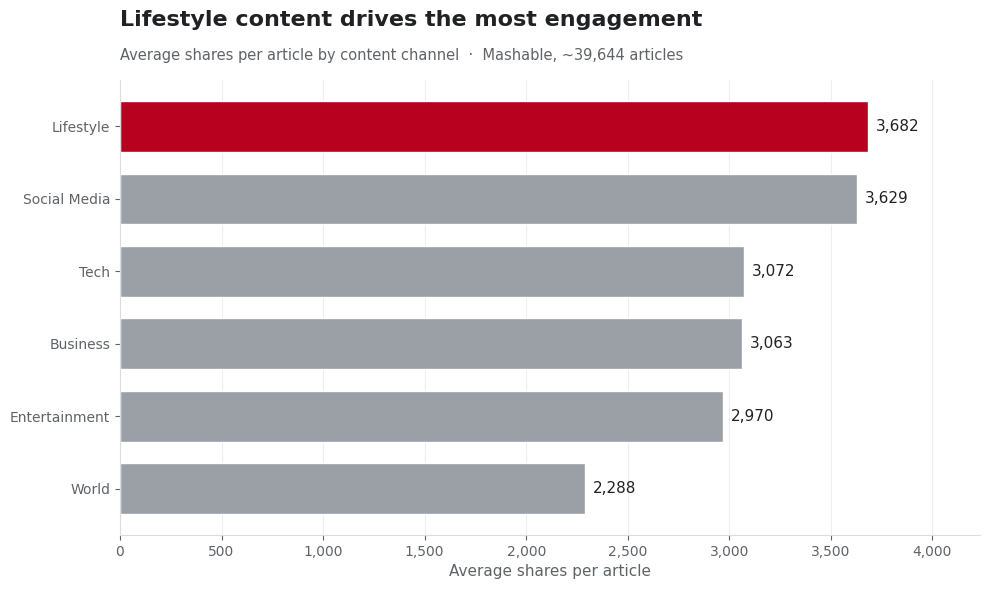

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Channel averages from your analysis
channel_avg = {
    "Lifestyle": 3682, "Social Media": 3629, "Tech": 3072,
    "Business": 3063, "Entertainment": 2970, "World": 2288,
}

items  = sorted(channel_avg.items(), key=lambda x: x[1])   # ascending -> biggest on top
labels = [k for k, v in items]
values = [v for k, v in items]
colors = ["#B8001F" if lab == "Lifestyle" else "#9AA0A6" for lab in labels]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(labels, values, color=colors, edgecolor="white", height=0.7)

for bar, val in zip(bars, values):
    ax.text(val + 40, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", ha="left", fontsize=11, color="#202124")

ax.text(0, 1.12, "Lifestyle content drives the most engagement",
        transform=ax.transAxes, fontsize=16, fontweight="bold", color="#202124")
ax.text(0, 1.045, "Average shares per article by content channel  ·  Mashable, ~39,644 articles",
        transform=ax.transAxes, fontsize=10.5, color="#5F6368")

ax.set_xlabel("Average shares per article", fontsize=11, color="#5F6368")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.set_xlim(0, max(values) * 1.15)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
ax.spines["left"].set_color("#DADCE0"); ax.spines["bottom"].set_color("#DADCE0")
ax.tick_params(colors="#5F6368")
ax.grid(axis="x", color="#EEEEEE", linewidth=0.8); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("channel_shares.png", dpi=150, bbox_inches="tight")
plt.show()

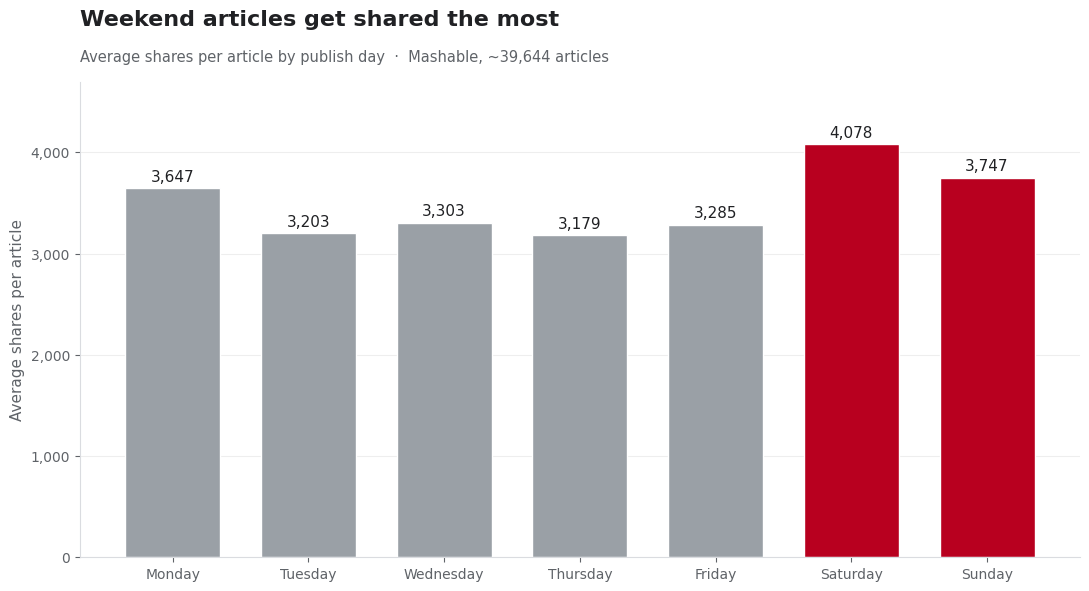

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load the cleaned data so this cell stands on its own
df = pd.read_csv("OnlineNewsPopularity_CLEANED.csv")

# Mashable column names ship with leading spaces — strip them so lookups work
df.columns = df.columns.str.strip()

# Pull the 7 day averages straight from the data
day_cols = {
    "Monday":"weekday_is_monday", "Tuesday":"weekday_is_tuesday",
    "Wednesday":"weekday_is_wednesday", "Thursday":"weekday_is_thursday",
    "Friday":"weekday_is_friday", "Saturday":"weekday_is_saturday", "Sunday":"weekday_is_sunday",
}
day_avg = {day: df.loc[df[col] == 1, "shares"].mean() for day, col in day_cols.items()}

order  = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
values = [day_avg[d] for d in order]
colors = ["#B8001F" if d in ("Saturday","Sunday") else "#9AA0A6" for d in order]  # weekends in red

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(order, values, color=colors, edgecolor="white", width=0.7)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 40, f"{val:,.0f}",
            ha="center", va="bottom", fontsize=11, color="#202124")

ax.text(0, 1.12, "Weekend articles get shared the most",
        transform=ax.transAxes, fontsize=16, fontweight="bold", color="#202124")
ax.text(0, 1.045, "Average shares per article by publish day  ·  Mashable, ~39,644 articles",
        transform=ax.transAxes, fontsize=10.5, color="#5F6368")

ax.set_ylabel("Average shares per article", fontsize=11, color="#5F6368")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylim(0, max(values) * 1.15)
for s in ["top","right"]: ax.spines[s].set_visible(False)
ax.spines["left"].set_color("#DADCE0"); ax.spines["bottom"].set_color("#DADCE0")
ax.tick_params(colors="#5F6368")
ax.grid(axis="y", color="#EEEEEE", linewidth=0.8); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("dayofweek_shares.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
import sqlite3
import pandas as pd

# Load cleaned data so the cell stands on its own
df = pd.read_csv("OnlineNewsPopularity_CLEANED.csv")
df.columns = df.columns.str.strip()

# --- Turn the one-hot flags into readable channel + weekday columns ---
channel_map = {
    "data_channel_is_lifestyle":"Lifestyle", "data_channel_is_entertainment":"Entertainment",
    "data_channel_is_bus":"Business", "data_channel_is_socmed":"Social Media",
    "data_channel_is_tech":"Tech", "data_channel_is_world":"World",
}
weekday_map = {
    "weekday_is_monday":"Monday","weekday_is_tuesday":"Tuesday","weekday_is_wednesday":"Wednesday",
    "weekday_is_thursday":"Thursday","weekday_is_friday":"Friday",
    "weekday_is_saturday":"Saturday","weekday_is_sunday":"Sunday",
}
chan_cols, wk_cols = list(channel_map), list(weekday_map)
df["channel"] = df[chan_cols].idxmax(axis=1).map(channel_map)
df.loc[df[chan_cols].sum(axis=1) == 0, "channel"] = "Uncategorized"   # articles with no channel flag
df["weekday"] = df[wk_cols].idxmax(axis=1).map(weekday_map)

# --- Build the SQLite database and load the table ---
conn = sqlite3.connect("content_engagement.db")
df.to_sql("articles", conn, if_exists="replace", index=False)   # table is named "articles"

# --- Query 1: average shares by channel (ranked) ---
q_channel = """
SELECT channel,
       COUNT(*)            AS article_count,
       ROUND(AVG(shares))  AS avg_shares
FROM articles
WHERE channel != 'Uncategorized'
GROUP BY channel
ORDER BY avg_shares DESC;
"""

# --- Query 2: average shares by publish day (ranked) ---
q_day = """
SELECT weekday,
       COUNT(*)            AS article_count,
       ROUND(AVG(shares))  AS avg_shares
FROM articles
GROUP BY weekday
ORDER BY avg_shares DESC;
"""

print("=== Average shares by channel ===")
print(pd.read_sql_query(q_channel, conn).to_string(index=False))
print("\n=== Average shares by publish day ===")
print(pd.read_sql_query(q_day, conn).to_string(index=False))
conn.close()

# --- Save the queries to a .sql file for the repo ---
with open("queries.sql", "w", encoding="utf-8") as f:
    f.write("""-- Content Engagement Analysis — SQL queries
-- Database: content_engagement.db   |   Table: articles

-- 1) Average shares by content channel (ranked)
SELECT channel,
       COUNT(*)            AS article_count,
       ROUND(AVG(shares))  AS avg_shares
FROM articles
WHERE channel != 'Uncategorized'
GROUP BY channel
ORDER BY avg_shares DESC;

-- 2) Average shares by publish day (ranked)
SELECT weekday,
       COUNT(*)            AS article_count,
       ROUND(AVG(shares))  AS avg_shares
FROM articles
GROUP BY weekday
ORDER BY avg_shares DESC;
""")
print("\nSaved queries.sql")

=== Average shares by channel ===
      channel  article_count  avg_shares
    Lifestyle           2099      3682.0
 Social Media           2323      3629.0
         Tech           7346      3072.0
     Business           6258      3063.0
Entertainment           7057      2970.0
        World           8427      2288.0

=== Average shares by publish day ===
  weekday  article_count  avg_shares
 Saturday           2453      4078.0
   Sunday           2737      3747.0
   Monday           6661      3647.0
Wednesday           7435      3303.0
   Friday           5701      3285.0
  Tuesday           7390      3203.0
 Thursday           7267      3179.0

Saved queries.sql


In [8]:
import sqlite3
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
# If openpyxl isn't installed yet: pip install openpyxl

# --- Pull the summary tables from the database ---
conn = sqlite3.connect("content_engagement.db")
channel_df = pd.read_sql_query("""
    SELECT channel, COUNT(*) AS articles, ROUND(AVG(shares)) AS avg_shares
    FROM articles WHERE channel != 'Uncategorized'
    GROUP BY channel ORDER BY avg_shares DESC;""", conn)
day_df = pd.read_sql_query("""
    SELECT weekday, COUNT(*) AS articles, ROUND(AVG(shares)) AS avg_shares
    FROM articles GROUP BY weekday ORDER BY avg_shares DESC;""", conn)
conn.close()

# --- Styling ---
RED = "B8001F"
white_bold = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
title_font = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
bold = Font(name="Calibri", size=11, bold=True)
base = Font(name="Calibri", size=11)
red_fill = PatternFill("solid", fgColor=RED)
center = Alignment(horizontal="center", vertical="center")
left = Alignment(horizontal="left", vertical="center", wrap_text=True)
thin = Side(style="thin", color="DDDDDD")
border = Border(left=thin, right=thin, top=thin, bottom=thin)

def style_header(ws, row, ncols):
    for c in range(1, ncols+1):
        cell = ws.cell(row=row, column=c)
        cell.font = white_bold; cell.fill = red_fill
        cell.alignment = center; cell.border = border

wb = Workbook()

# ===== Sheet 1: Key Findings =====
ws1 = wb.active; ws1.title = "Key Findings"
ws1.merge_cells("A1:C1"); ws1["A1"] = "Content Engagement Analysis — Key Findings"
ws1["A1"].font = title_font; ws1["A1"].fill = red_fill; ws1["A1"].alignment = center
ws1.merge_cells("A2:C2"); ws1["A2"] = "Dataset: Mashable Online News Popularity  ·  ~39,644 articles"
ws1["A2"].font = Font(name="Calibri", size=10, italic=True, color="666666"); ws1["A2"].alignment = center
ws1["A4"] = "Headline"; ws1["A4"].font = bold
ws1.merge_cells("B4:C4")
ws1["B4"] = ("Engagement is driven more by WHAT category and WHEN an article is published "
             "than by its length or structure.")
ws1["B4"].font = base; ws1["B4"].alignment = left
for i, h in enumerate(["Finding", "Strength", "Detail"], 1): ws1.cell(row=6, column=i, value=h)
style_header(ws1, 6, 3)
rows = [("Content features", "Weak", "Links, images, subjectivity, and length all correlate below 0.05 with shares."),
        ("Content channel", "Strong", "Lifestyle (3,682 avg) outshares World (2,288) by ~61%."),
        ("Publish day", "Moderate", "Weekends lead — Saturday (4,078) is ~28% above Thursday (3,179).")]
for r, (a, b, c) in enumerate(rows, start=7):
    ws1.cell(row=r, column=1, value=a).font = bold
    ws1.cell(row=r, column=2, value=b).font = base
    ws1.cell(row=r, column=3, value=c).font = base; ws1.cell(row=r, column=3).alignment = left
    for col in range(1, 4): ws1.cell(row=r, column=col).border = border
ws1.column_dimensions["A"].width = 20; ws1.column_dimensions["B"].width = 12; ws1.column_dimensions["C"].width = 62

# ===== Sheets 2 & 3: data tables with a live % formula =====
def data_sheet(ws, df, first_col):
    for i, h in enumerate([first_col, "Articles", "Avg Shares", "% Above Lowest"], 1): ws.cell(row=1, column=i, value=h)
    style_header(ws, 1, 4)
    for idx, row in df.iterrows():
        r = idx + 2
        ws.cell(row=r, column=1, value=row.iloc[0]).font = base
        ws.cell(row=r, column=2, value=int(row["articles"])).font = base;   ws.cell(row=r, column=2).number_format = "#,##0"
        ws.cell(row=r, column=3, value=int(row["avg_shares"])).font = base; ws.cell(row=r, column=3).number_format = "#,##0"
    last = len(df) + 1
    for r in range(2, last+1):
        ws.cell(row=r, column=4, value=f"=(C{r}-$C${last})/$C${last}")
        ws.cell(row=r, column=4).number_format = "0.0%"; ws.cell(row=r, column=4).font = base
    for r in range(1, last+1):
        for c in range(1, 5):
            ws.cell(row=r, column=c).border = border
            if c >= 2: ws.cell(row=r, column=c).alignment = center
    ws.column_dimensions["A"].width = 18
    for col in ["B", "C", "D"]: ws.column_dimensions[col].width = 15
    ws.freeze_panes = "A2"

data_sheet(wb.create_sheet("By Channel"), channel_df, "Channel")
data_sheet(wb.create_sheet("By Publish Day"), day_df, "Day")

wb.save("content_engagement_summary.xlsx")
print("Saved content_engagement_summary.xlsx")

Saved content_engagement_summary.xlsx
